# About Dataset

Data set taken from : https://datahack.analyticsvidhya.com/contest/practice-problem-loan-prediction-iii/

Problem Statement
About Company
Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan.

Problem
Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers. Here they have provided a partial data set.


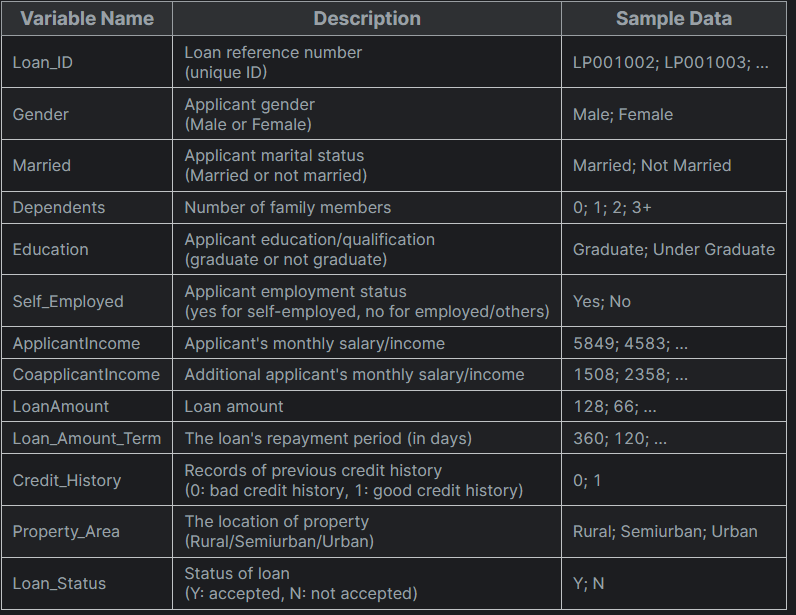

# import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the dataset
df = pd.read_csv('train_ctrUa4K.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# 1. Data Exploration



```
# This is formatted as code
```

## 1.1 Categorical variables


In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
df.Loan_ID.value_counts(dropna=False)

Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 614, dtype: int64

#### 1.1.1 gender

In [8]:

df.Gender.value_counts(dropna=False)

Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

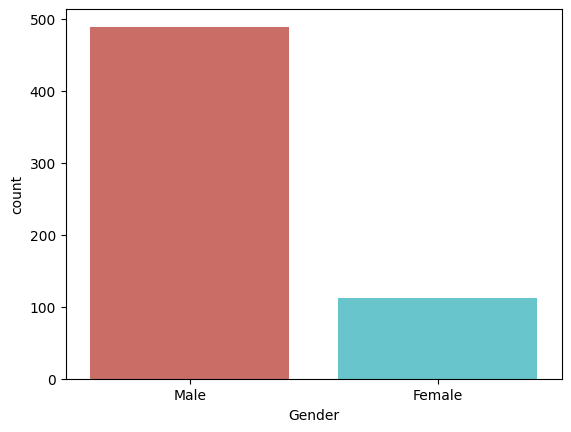

In [9]:
sns.countplot(x = "Gender", data = df, palette = 'hls')
plt.show()

In [10]:
countMale = len(df[df.Gender == 'Male'])
countFemale = len(df[df.Gender == 'Female'])
countNull = len(df[df.Gender.isnull()])
totalCount = len(df.Gender)
countMale, countFemale, countNull, totalCount

(489, 112, 13, 614)

In [11]:
print("Male Percentage: {:.2f}%".format((countMale/totalCount)*100))
print("Female Percentage: {:.2f}%".format((countFemale/totalCount)*100))
print("Missing values Percentage: {:.2f}%".format((countNull/totalCount)*100))


Male Percentage: 79.64%
Female Percentage: 18.24%
Missing values Percentage: 2.12%


#### 1.1.2 Marital Status

In [12]:
df.Married.value_counts(dropna=False)

Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

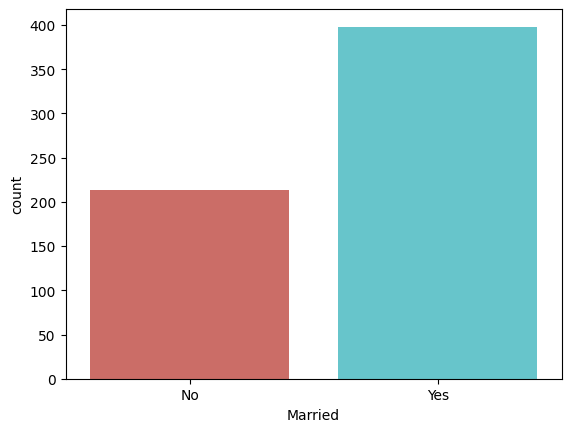

In [13]:
sns.countplot(x = "Married", data = df, palette = 'hls')
plt.show()

In [14]:
countMarried = len(df[df.Married == 'Yes'])
countUnmarried = len(df[df.Married == 'No'])
countNull = len(df[df.Married.isnull()])

print("Married Percentage: {:.2f}%".format((countMarried/totalCount)*100))
print("UnMarried Percentage: {:.2f}%".format((countUnmarried/totalCount)*100))
print("Missing Married Values Percentage: {:.2f}%".format((countNull/totalCount)*100))


Married Percentage: 64.82%
UnMarried Percentage: 34.69%
Missing Married Values Percentage: 0.49%


## TASK 1

1. Analyise for Education, SelfEmployed

#### 1.1.3 Credit Score

In [15]:
df.Credit_History.value_counts(dropna = False)

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

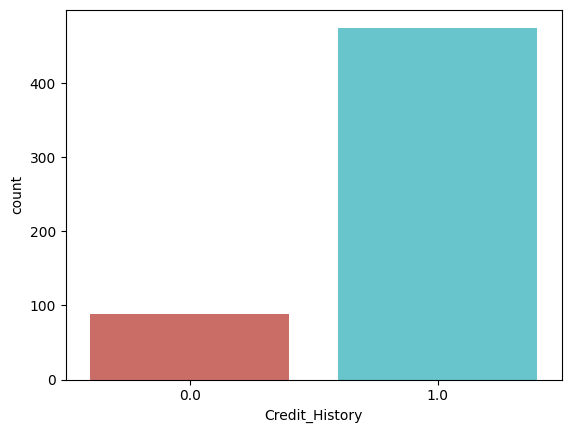

In [16]:
sns.countplot(x = 'Credit_History', data = df, palette  = 'hls')
plt.show()

#### 1.1.4 Loan Amount Term

In [17]:
df.Loan_Amount_Term.value_counts(dropna=False)

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
NaN       14
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

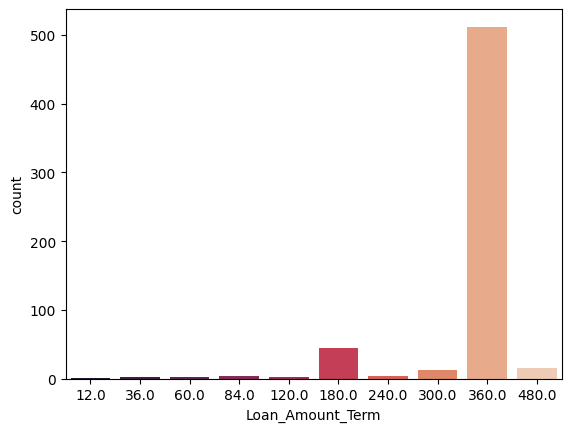

In [18]:
sns.countplot(x = "Loan_Amount_Term", data = df, palette='rocket')
plt.show()

In [19]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

#### 1.1.5 Property Area

In [20]:
df.Property_Area.value_counts(dropna=False)

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

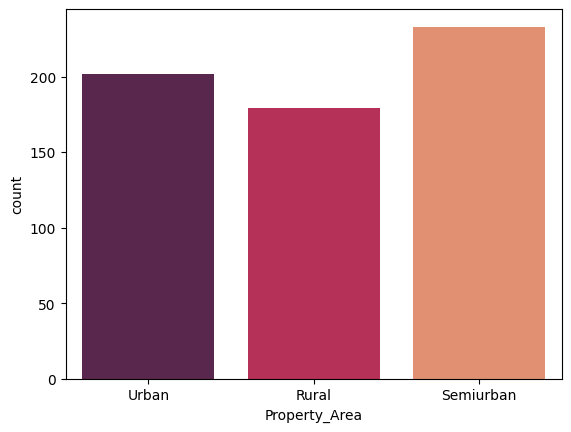

In [21]:
sns.countplot(x = "Property_Area", data = df, palette='rocket')
plt.show()

#### 1.1.6 Loan Status

In [22]:
df.Loan_Status.value_counts(dropna=False)

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [23]:
countYes = len(df[df.Loan_Status == 'Y'])
countNo = len(df[df.Loan_Status == 'N'])

print("Approved Loan Percentage: {:.2f}%".format((countYes/totalCount)*100))
print("Rejected Loan Percentage: {:.2f}%".format((countNo/totalCount)*100))


Approved Loan Percentage: 68.73%
Rejected Loan Percentage: 31.27%


## 1.2 Numerical variables


In [24]:
df.select_dtypes(include=np.number).columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [25]:
df.select_dtypes(include=np.number).describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#### 1.2.1 HISTPLOT - UNIVARIATE ANALYSIS

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

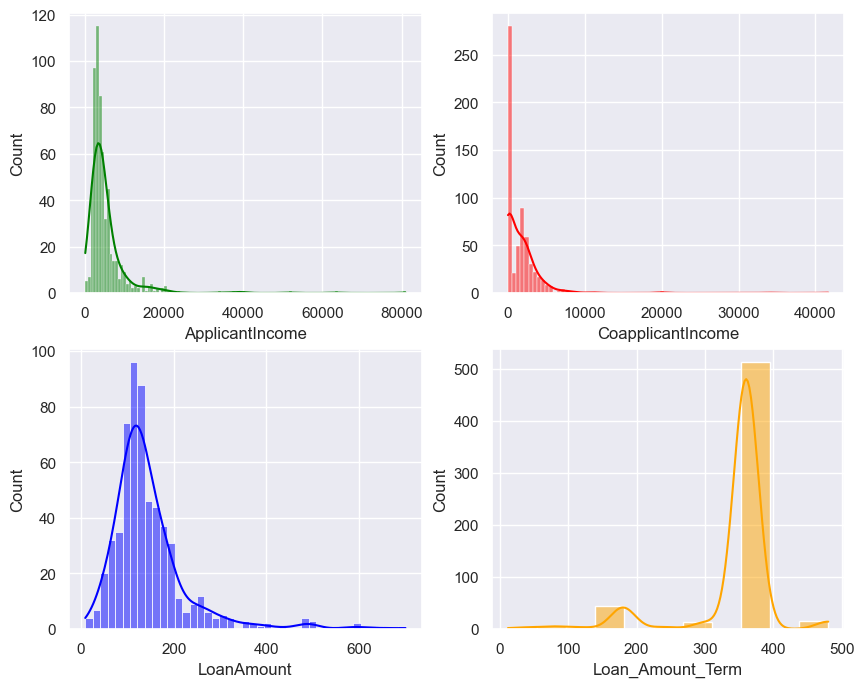

In [26]:
sns.set(style='darkgrid')

fig,axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(data=df, x = "ApplicantIncome",ax = axs[0,0], kde=True, color='green')
sns.histplot(data=df, x = "CoapplicantIncome",ax = axs[0,1], kde=True, color='red')
sns.histplot(data=df, x = "LoanAmount",ax = axs[1,0], kde=True, color='blue')
sns.histplot(data=df, x = "Loan_Amount_Term",ax = axs[1,1], kde=True, color='orange')



#### 1.2.1 Violin Plot - UNIVARIATE ANALYSIS

<Axes: ylabel='Loan_Amount_Term'>

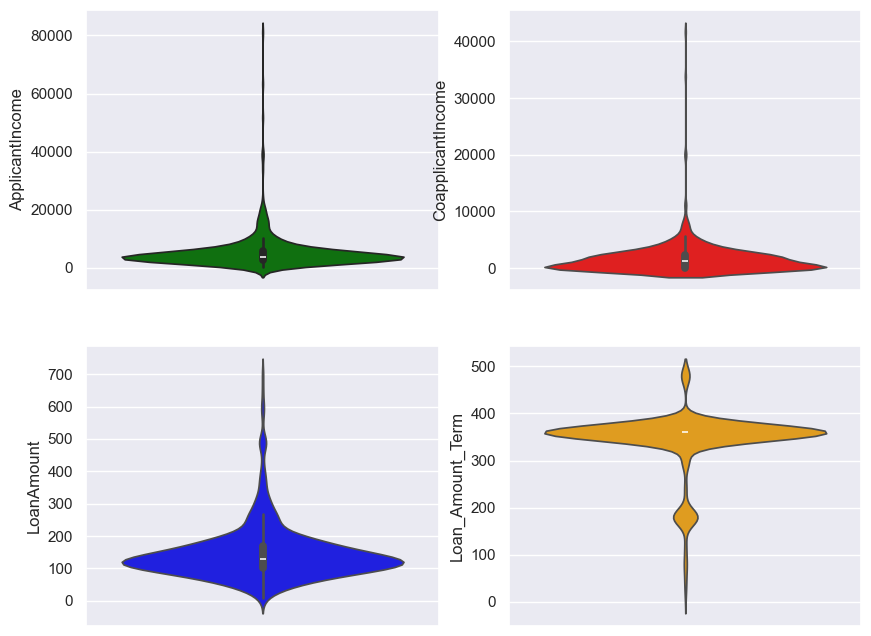

In [27]:
sns.set(style='darkgrid')

fig,axs = plt.subplots(2,2, figsize=(10,8))

sns.violinplot(data=df, y = "ApplicantIncome",ax = axs[0,0], color='green')
sns.violinplot(data=df, y = "CoapplicantIncome",ax = axs[0,1], color='red')
sns.violinplot(data=df, y = "LoanAmount",ax = axs[1,0], color='blue')
sns.violinplot(data=df, y = "Loan_Amount_Term",ax = axs[1,1], color='orange')



###

#### 1.2.3 BIVARIATE ANALYSIS

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


<Axes: >

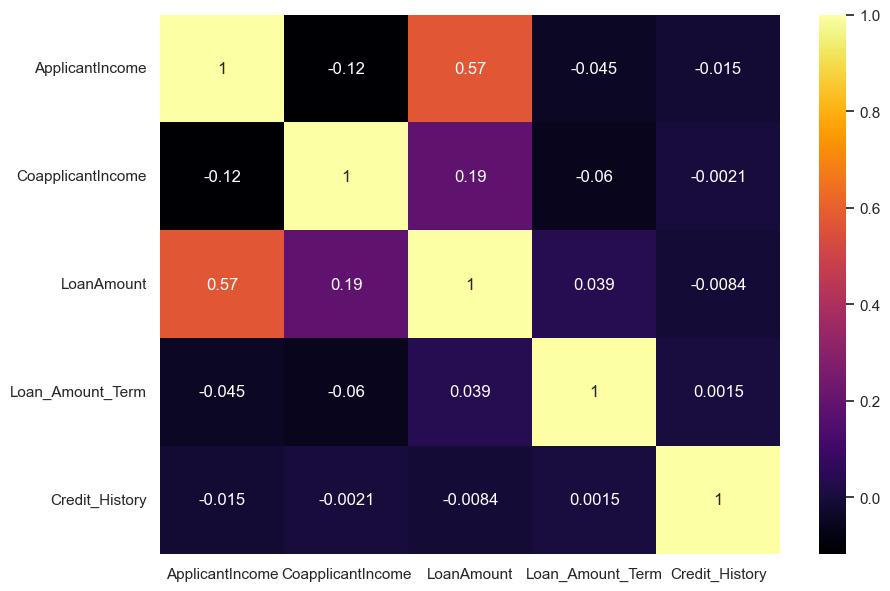

In [29]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='inferno')

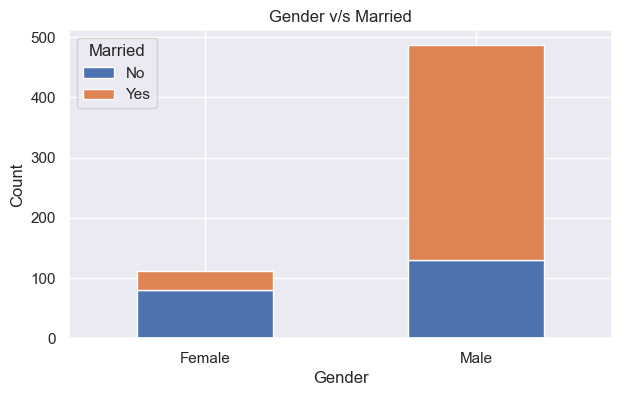

In [30]:
pd.crosstab(df.Gender, df.Married).plot(kind='bar', stacked =True, figsize=(7,4))
plt.title("Gender v/s Married")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

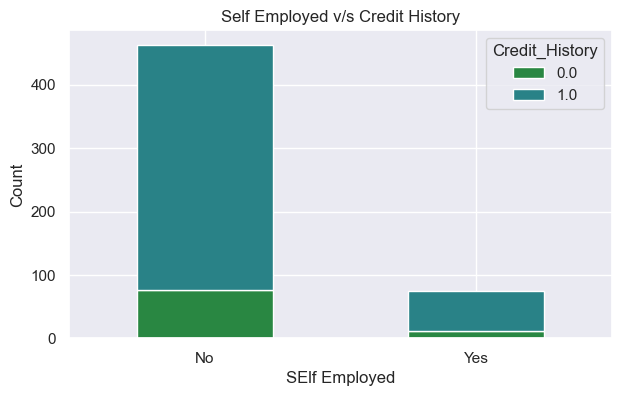

In [31]:
pd.crosstab(df.Self_Employed, df.Credit_History).plot(kind='bar', stacked =True, figsize=(7,4),
                                                      color = ['#298742','#298287'])
plt.title("Self Employed v/s Credit History")
plt.xlabel("SElf Employed")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

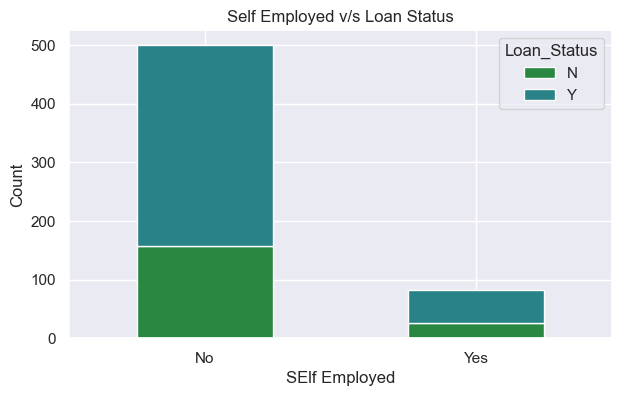

In [32]:
pd.crosstab(df.Self_Employed, df.Loan_Status).plot(kind='bar', stacked =True, figsize=(7,4),
                                                      color = ['#298742','#298287'])
plt.title("Self Employed v/s Loan Status")
plt.xlabel("SElf Employed")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

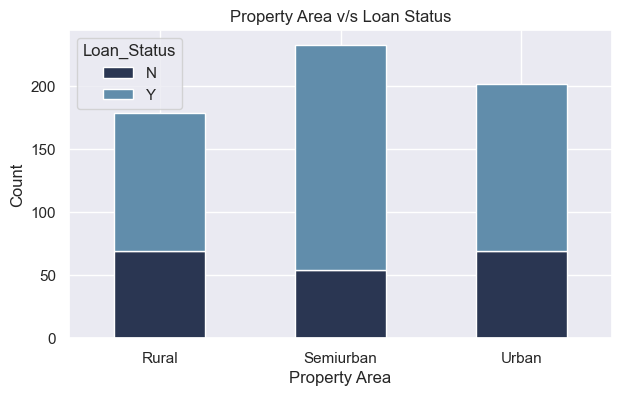

In [33]:
pd.crosstab(df.Property_Area, df.Loan_Status).plot(kind='bar', stacked =True, figsize=(7,4),
                                                      color = ['#2a3652','#618dab'])
plt.title("Property Area v/s Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [34]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

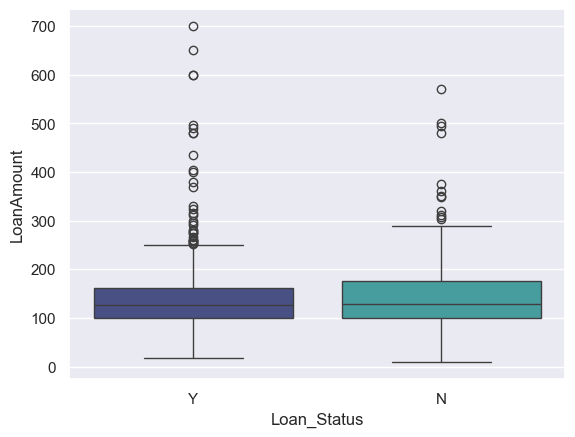

In [36]:
sns.boxplot(x = 'Loan_Status', y='LoanAmount', data = df, palette = 'mako')

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

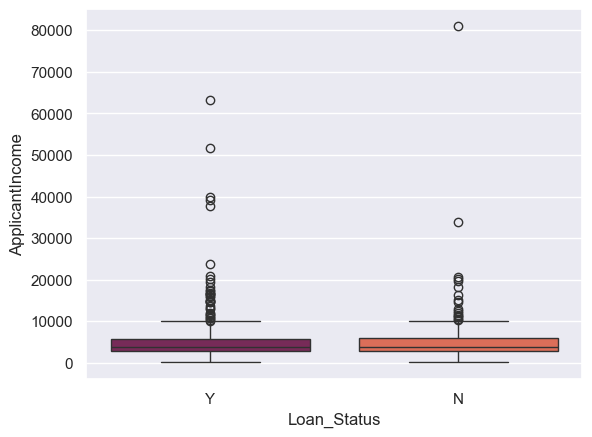

In [37]:
sns.boxplot(x = 'Loan_Status', y='ApplicantIncome', data = df, palette = 'rocket')

<Axes: xlabel='Loan_Status', ylabel='CoapplicantIncome'>

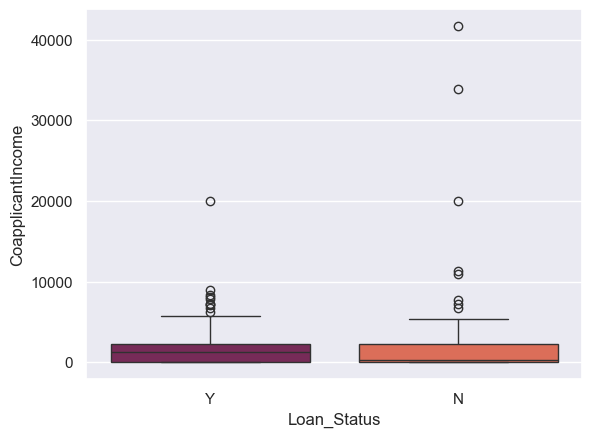

In [38]:
sns.boxplot(x = 'Loan_Status', y='CoapplicantIncome', data = df, palette = 'rocket')

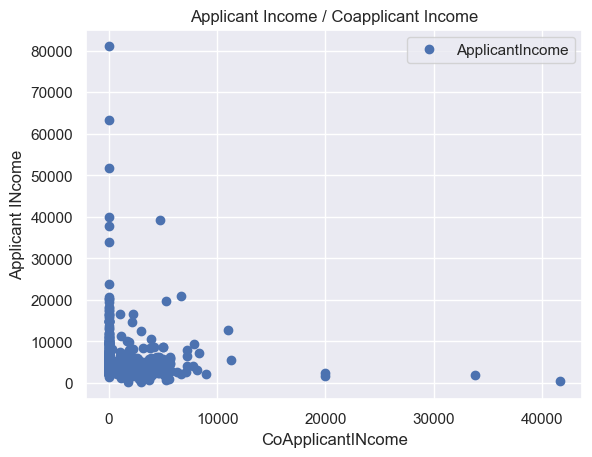

In [39]:
df.plot(x = 'CoapplicantIncome', y='ApplicantIncome', style = 'o')
plt.title('Applicant Income / Coapplicant Income')
plt.xlabel("CoApplicantINcome")
plt.ylabel("Applicant INcome")
plt.show()

## NULL VALUES

In [40]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: >

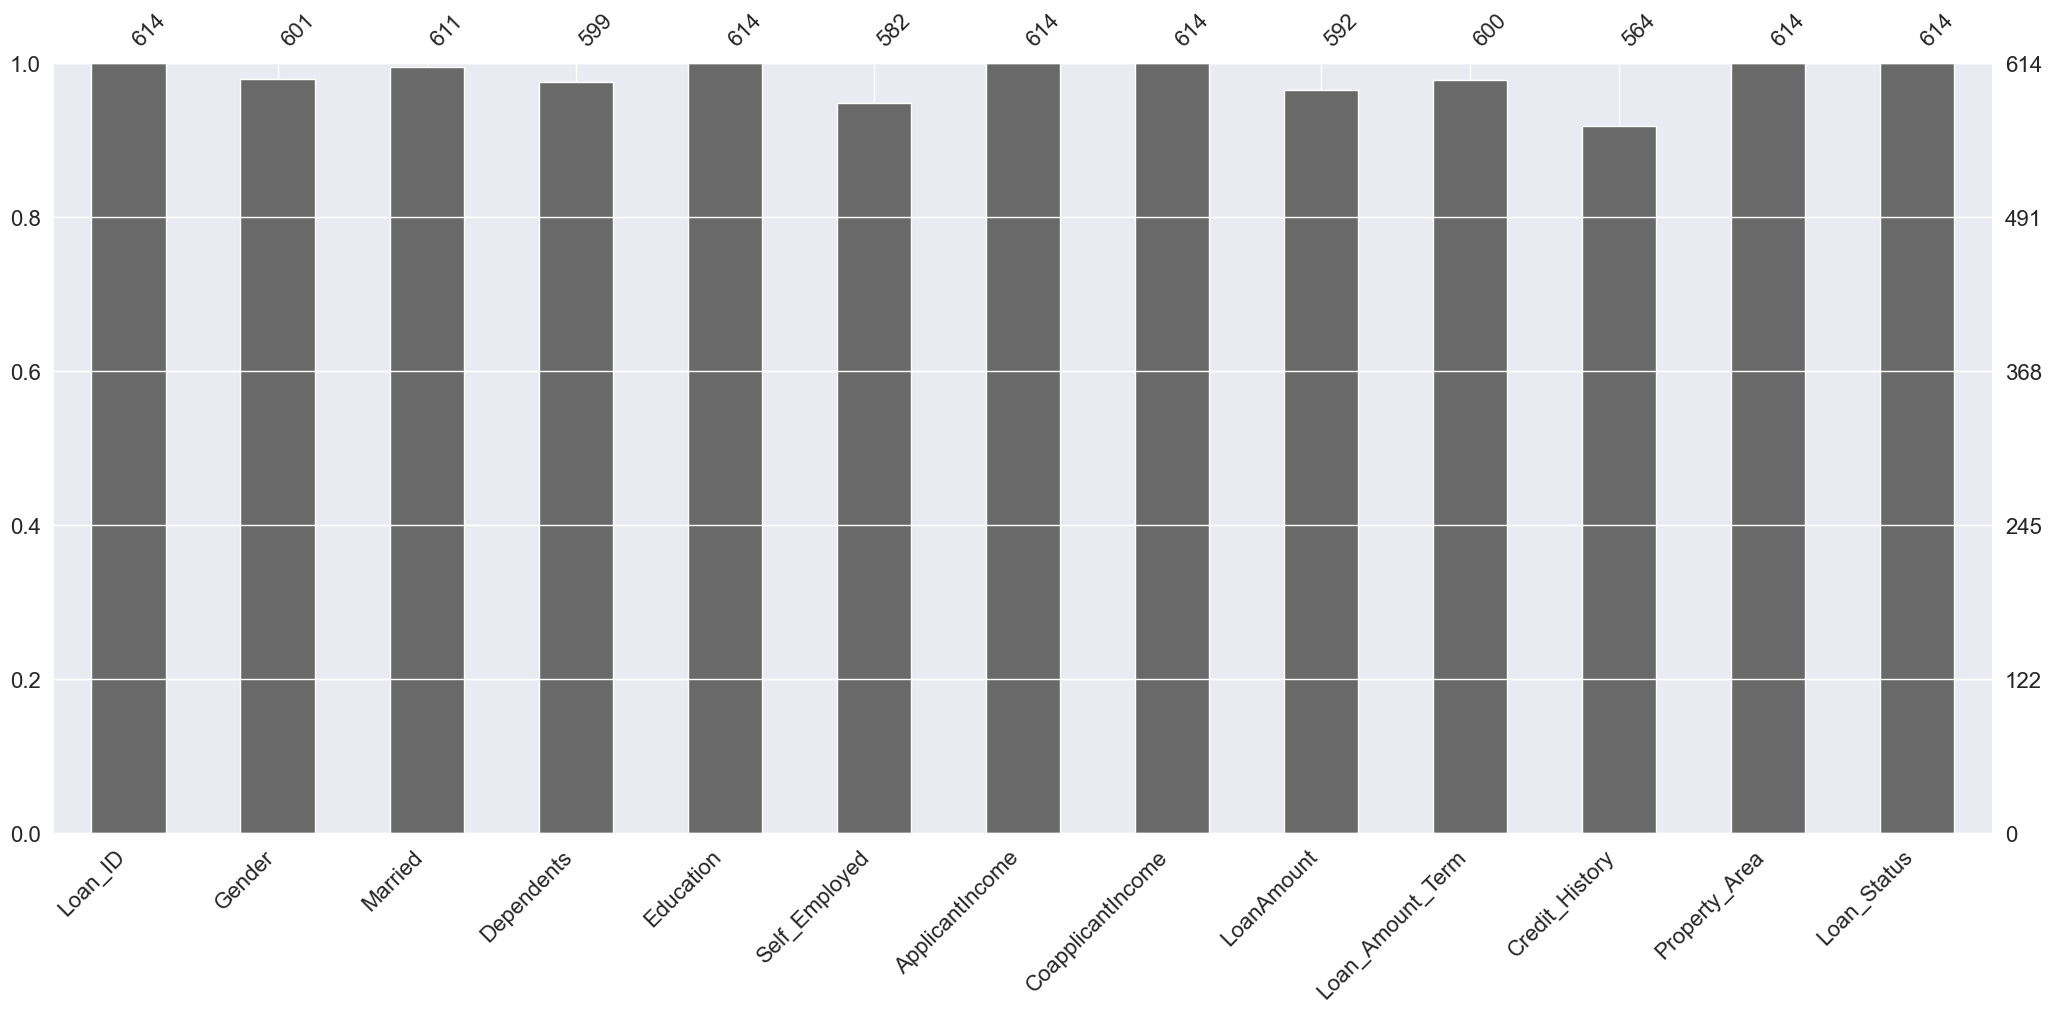

In [41]:
import missingno as mso
mso.bar(df)

In [42]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#2. Data Preprocessing

### 2.1 Drop Faltu ke Variables

In [43]:
df = df.drop(['Loan_ID'], axis = 1)

In [44]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [45]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

### 2.2 Handle Missing Values

for imputation techniques - https://www.geeksforgeeks.org/machine-learning/data-imputation-techniques-in-ml/

In [46]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [47]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

In [48]:
df['Married'].fillna(df['Married'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace=True)

In [49]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [50]:
df['LoanAmount'].mean(), df['LoanAmount'].mode(), df['LoanAmount'].median()

(np.float64(146.41216216216216),
 0    120.0
 Name: LoanAmount, dtype: float64,
 np.float64(128.0))

In [51]:
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

In [52]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

<Axes: >

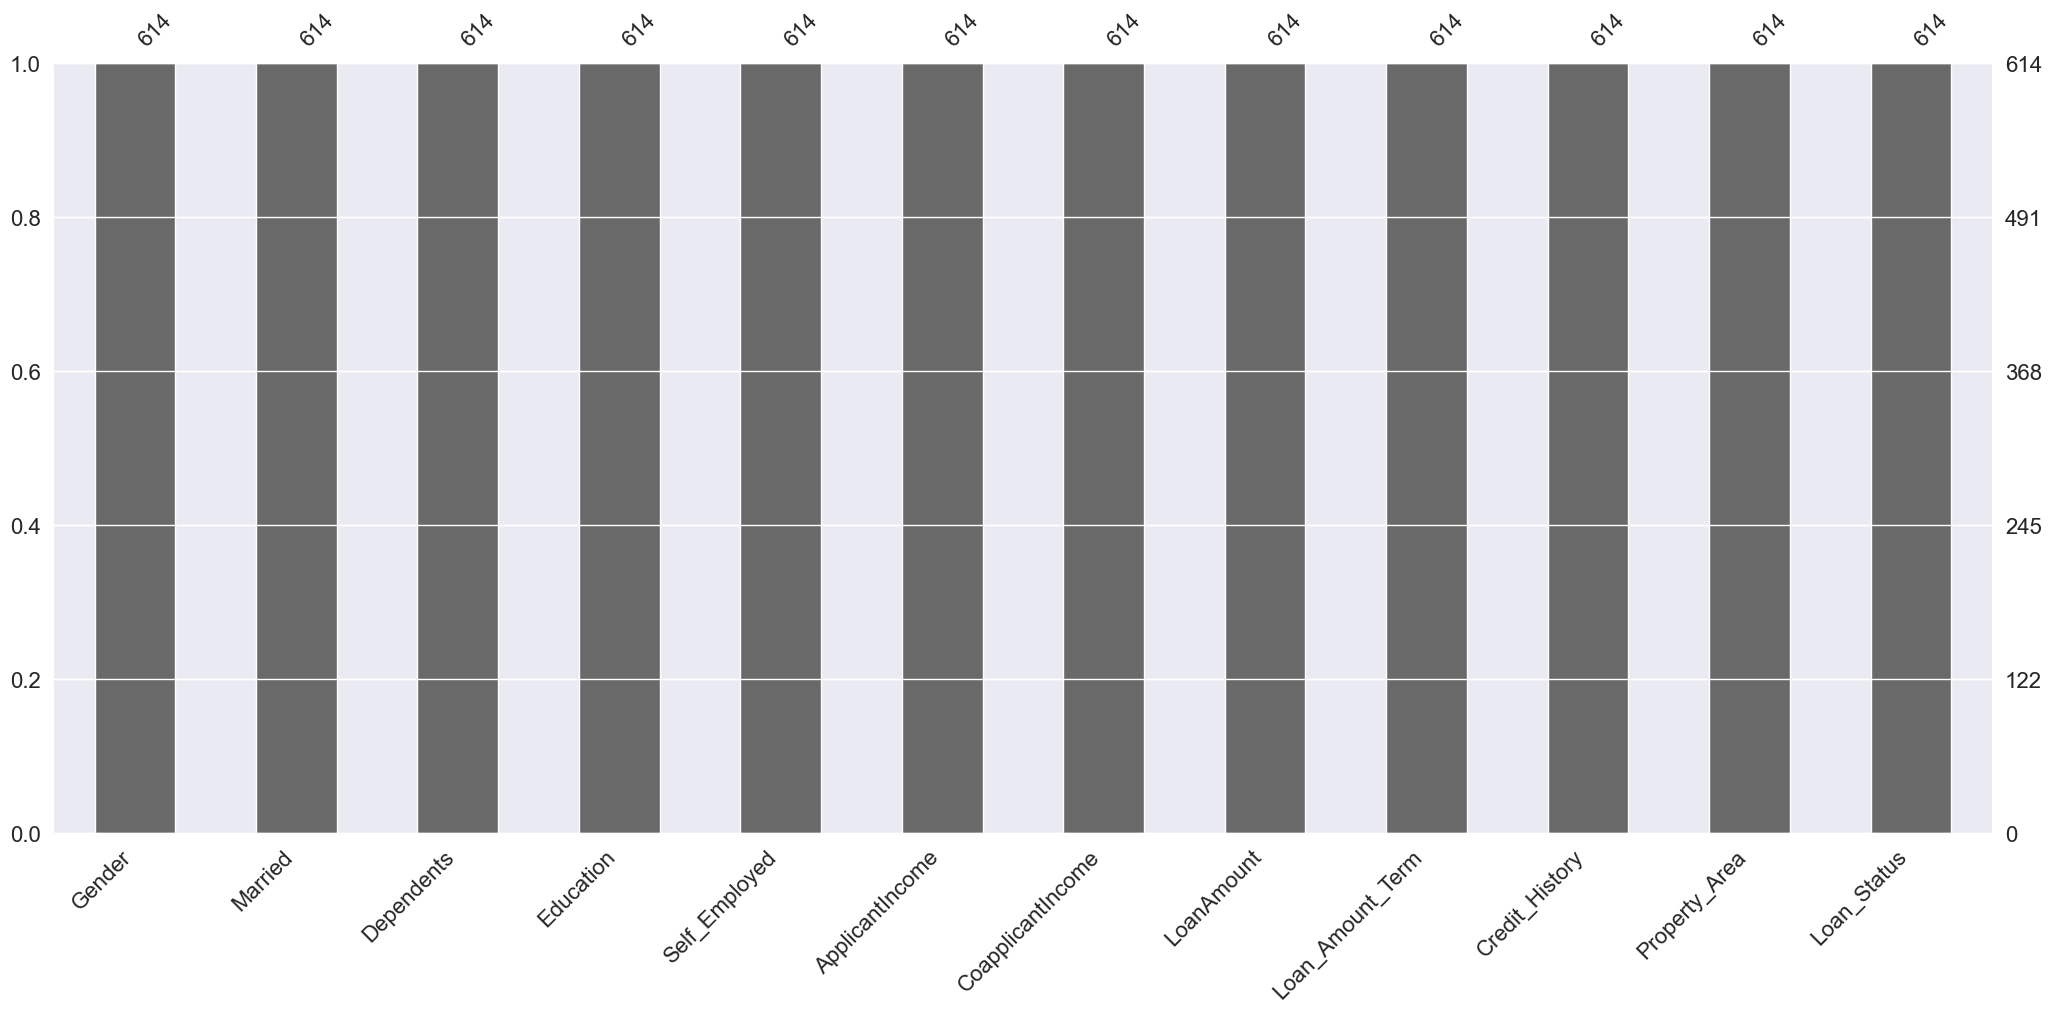

In [53]:
mso.bar(df)

### 2.3 Categoriacal Variable to Machine Undestandable variables

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [55]:
df = pd.get_dummies(df)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    int64  
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Gender_Female            614 non-null    bool   
 6   Gender_Male              614 non-null    bool   
 7   Married_No               614 non-null    bool   
 8   Married_Yes              614 non-null    bool   
 9   Dependents_0             614 non-null    bool   
 10  Dependents_1             614 non-null    bool   
 11  Dependents_2             614 non-null    bool   
 12  Dependents_3+            614 non-null    bool   
 13  Education_Graduate       614 non-null    bool   
 14  Education_Not Graduate   6

In [57]:
df = df.drop(['Gender_Female', 'Married_No', 'Education_Not Graduate', 'Self_Employed_No',
         'Loan_Status_N'], axis = 1)

In [58]:
df.head()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,146.412162,360.0,1.0,True,False,True,False,False,False,True,False,False,False,True,True
1,4583,1508.0,128.000000,360.0,1.0,True,True,False,True,False,False,True,False,True,False,False,False
2,3000,0.0,66.000000,360.0,1.0,True,True,True,False,False,False,True,True,False,False,True,True
3,2583,2358.0,120.000000,360.0,1.0,True,True,True,False,False,False,False,False,False,False,True,True
4,6000,0.0,141.000000,360.0,1.0,True,False,True,False,False,False,True,False,False,False,True,True


In [59]:
newColName = {'Married_Yes': 'Married',
'Self_Employed_Yes': 'Self_Employed',
'Loan_Status_Y': 'Loan_Status'}

df.rename(columns = newColName, inplace = True)

In [60]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Self_Employed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,5849,0.0,146.412162,360.0,1.0,True,False,True,False,False,False,True,False,False,False,True,True
1,4583,1508.0,128.000000,360.0,1.0,True,True,False,True,False,False,True,False,True,False,False,False
2,3000,0.0,66.000000,360.0,1.0,True,True,True,False,False,False,True,True,False,False,True,True
3,2583,2358.0,120.000000,360.0,1.0,True,True,True,False,False,False,False,False,False,False,True,True
4,6000,0.0,141.000000,360.0,1.0,True,False,True,False,False,False,True,False,False,False,True,True


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    int64  
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Gender_Male              614 non-null    bool   
 6   Married                  614 non-null    bool   
 7   Dependents_0             614 non-null    bool   
 8   Dependents_1             614 non-null    bool   
 9   Dependents_2             614 non-null    bool   
 10  Dependents_3+            614 non-null    bool   
 11  Education_Graduate       614 non-null    bool   
 12  Self_Employed            614 non-null    bool   
 13  Property_Area_Rural      614 non-null    bool   
 14  Property_Area_Semiurban  6

In [62]:
for col in df.columns:
  if(df[col].dtype=='bool'):
    df[col] = df[col].astype(np.uint8)

In [63]:
df.dtypes

ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Gender_Male                  uint8
Married                      uint8
Dependents_0                 uint8
Dependents_1                 uint8
Dependents_2                 uint8
Dependents_3+                uint8
Education_Graduate           uint8
Self_Employed                uint8
Property_Area_Rural          uint8
Property_Area_Semiurban      uint8
Property_Area_Urban          uint8
Loan_Status                  uint8
dtype: object

### 2.4 Outliers se bye bye

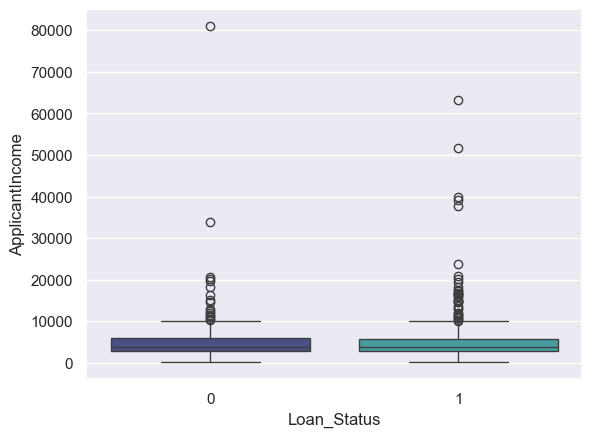

In [64]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df, palette="mako");

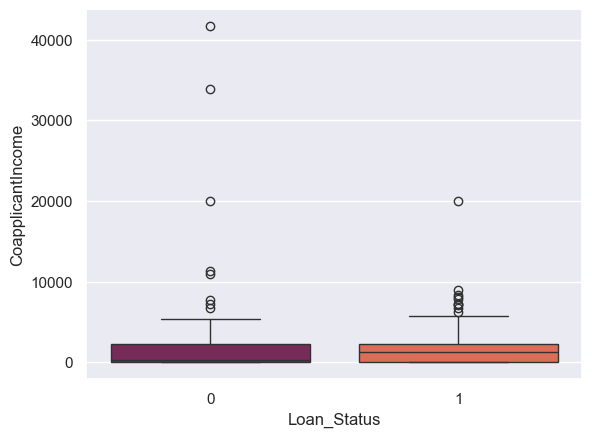

In [65]:
sns.boxplot(y="CoapplicantIncome", x="Loan_Status", data=df, palette="rocket");


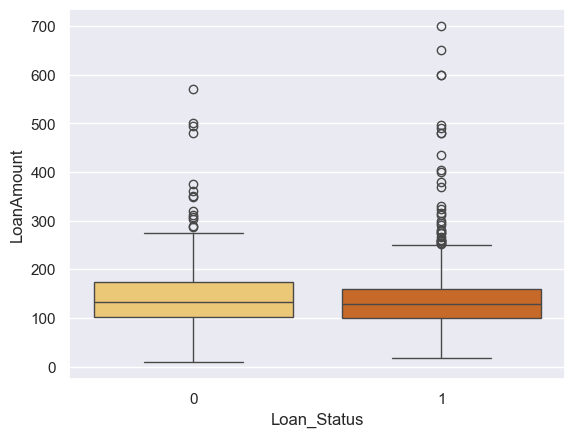

In [66]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df, palette="YlOrBr");


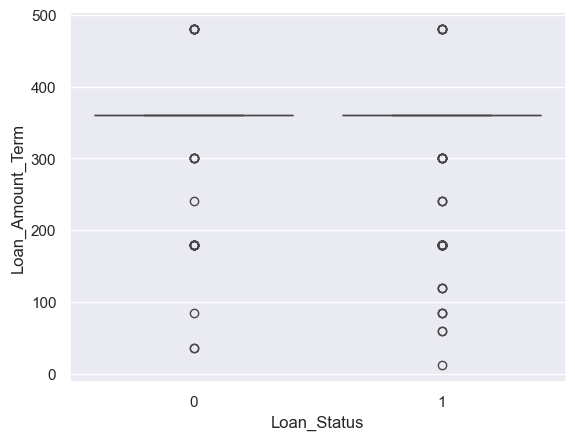

In [67]:
sns.boxplot(x="Loan_Status", y="Loan_Amount_Term", data=df, palette="YlOrBr");


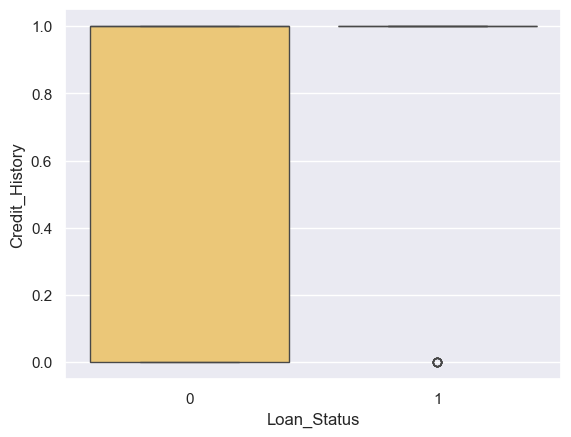

In [68]:
sns.boxplot(x="Loan_Status", y="Credit_History", data=df, palette="YlOrBr");


In [69]:
Q1 = df.quantile(0.25)
Q1

ApplicantIncome            2877.50
CoapplicantIncome             0.00
LoanAmount                  100.25
Loan_Amount_Term            360.00
Credit_History                1.00
Gender_Male                   1.00
Married                       0.00
Dependents_0                  0.00
Dependents_1                  0.00
Dependents_2                  0.00
Dependents_3+                 0.00
Education_Graduate            1.00
Self_Employed                 0.00
Property_Area_Rural           0.00
Property_Area_Semiurban       0.00
Property_Area_Urban           0.00
Loan_Status                   0.00
Name: 0.25, dtype: float64

In [70]:
Q3 = df.quantile(0.75)
Q3

ApplicantIncome            5795.00
CoapplicantIncome          2297.25
LoanAmount                  164.75
Loan_Amount_Term            360.00
Credit_History                1.00
Gender_Male                   1.00
Married                       1.00
Dependents_0                  1.00
Dependents_1                  0.00
Dependents_2                  0.00
Dependents_3+                 0.00
Education_Graduate            1.00
Self_Employed                 0.00
Property_Area_Rural           1.00
Property_Area_Semiurban       1.00
Property_Area_Urban           1.00
Loan_Status                   1.00
Name: 0.75, dtype: float64

In [71]:
IQR = Q3 - Q1
IQR

ApplicantIncome            2917.50
CoapplicantIncome          2297.25
LoanAmount                   64.50
Loan_Amount_Term              0.00
Credit_History                0.00
Gender_Male                   0.00
Married                       1.00
Dependents_0                  1.00
Dependents_1                  0.00
Dependents_2                  0.00
Dependents_3+                 0.00
Education_Graduate            0.00
Self_Employed                 0.00
Property_Area_Rural           1.00
Property_Area_Semiurban       1.00
Property_Area_Urban           1.00
Loan_Status                   1.00
dtype: float64

In [72]:
(df < (Q1 - 1.5 * IQR)).sum()

ApplicantIncome              0
CoapplicantIncome            0
LoanAmount                   0
Loan_Amount_Term            73
Credit_History              89
Gender_Male                112
Married                      0
Dependents_0                 0
Dependents_1                 0
Dependents_2                 0
Dependents_3+                0
Education_Graduate         134
Self_Employed                0
Property_Area_Rural          0
Property_Area_Semiurban      0
Property_Area_Urban          0
Loan_Status                  0
dtype: int64

In [73]:
(df > (Q3 + 1.5 * IQR)).sum()

ApplicantIncome             50
CoapplicantIncome           18
LoanAmount                  41
Loan_Amount_Term            15
Credit_History               0
Gender_Male                  0
Married                      0
Dependents_0                 0
Dependents_1               102
Dependents_2               101
Dependents_3+               51
Education_Graduate           0
Self_Employed               82
Property_Area_Rural          0
Property_Area_Semiurban      0
Property_Area_Urban          0
Loan_Status                  0
dtype: int64

In [74]:
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

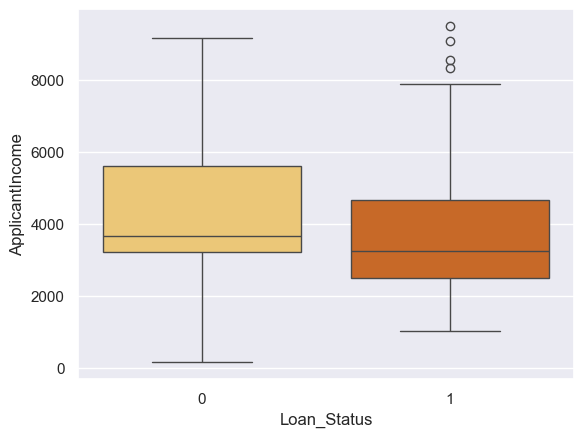

In [75]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df, palette="YlOrBr");


### 2.5 AAo Poonch kaat dete hai (Uniform Distribution)

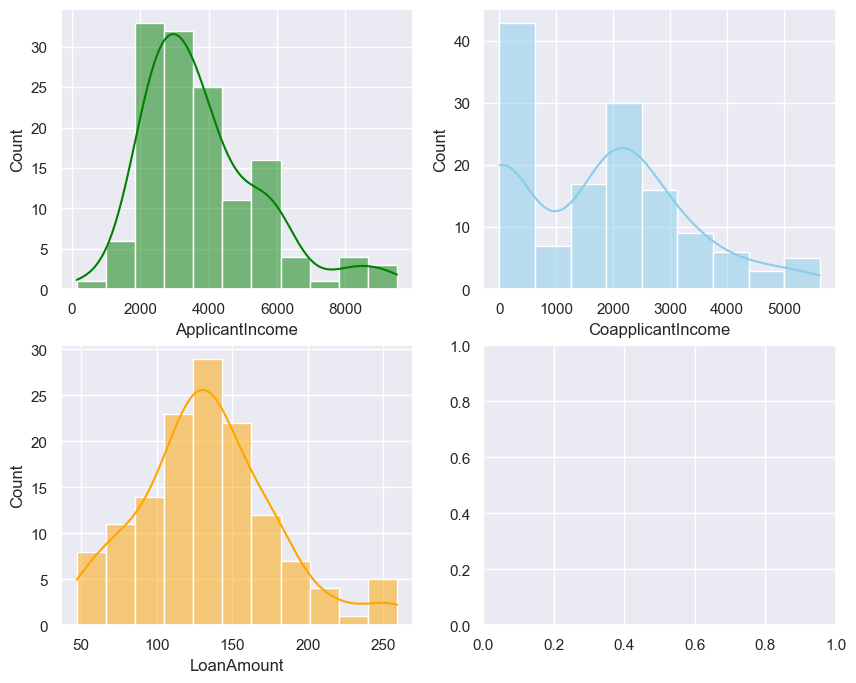

In [76]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="ApplicantIncome", kde=True, ax=axs[0, 0], color='green')
sns.histplot(data=df, x="CoapplicantIncome", kde=True, ax=axs[0, 1], color='skyblue')
sns.histplot(data=df, x="LoanAmount", kde=True, ax=axs[1, 0], color='orange');

In [77]:
df.ApplicantIncome = np.sqrt(df.ApplicantIncome)
df.LoanAmount = np.sqrt(df.LoanAmount)
df.CoapplicantIncome = np.sqrt(df.CoapplicantIncome)

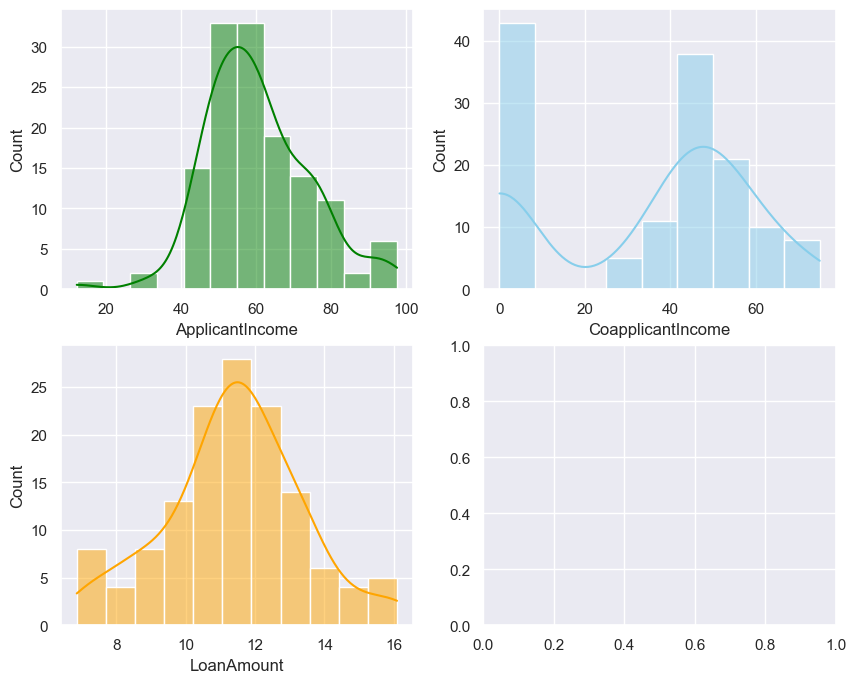

In [78]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="ApplicantIncome", kde=True, ax=axs[0, 0], color='green')
sns.histplot(data=df, x="CoapplicantIncome", kde=True, ax=axs[0, 1], color='skyblue')
sns.histplot(data=df, x="LoanAmount", kde=True, ax=axs[1, 0], color='orange');

In [79]:
X = df.drop(['Loan_Status'], axis = 1)
y = df['Loan_Status']

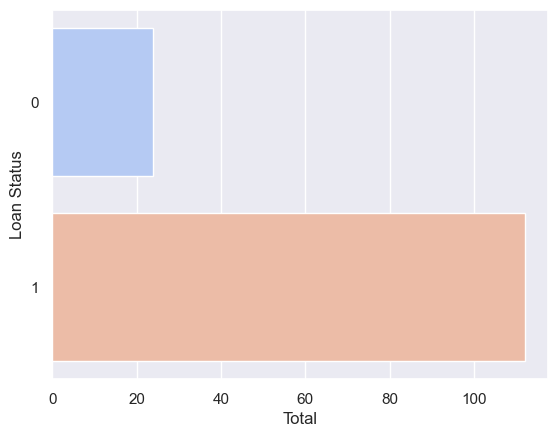

In [80]:
sns.set_theme(style="darkgrid")
sns.countplot(y=y, data=df, palette="coolwarm")
plt.ylabel('Loan Status')
plt.xlabel('Total')
plt.show()

In [81]:
from imblearn.over_sampling import SMOTE

X, y = SMOTE().fit_resample(X,y)

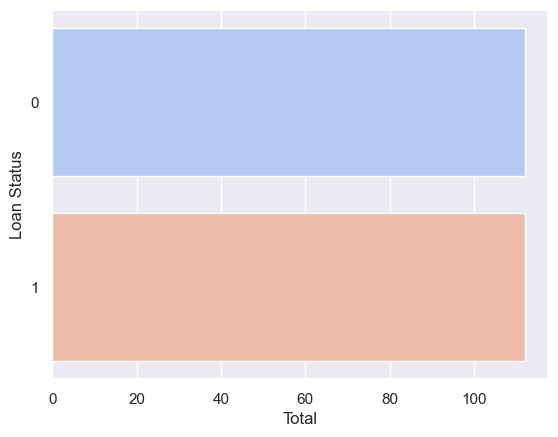

In [82]:
sns.set_theme(style="darkgrid")
sns.countplot(y=y, data=df, palette="coolwarm")
plt.ylabel('Loan Status')
plt.xlabel('Total')
plt.show()

In [83]:
X

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Self_Employed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,76.478755,0.000000,12.100089,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1
1,77.459667,0.000000,11.874342,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1
2,43.046487,53.291650,10.677078,360.0,1.0,1,0,1,0,0,0,1,0,1,0,0
3,70.356236,0.000000,11.180340,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1
4,50.990195,59.160798,10.723805,360.0,1.0,1,1,1,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,66.605134,0.000000,9.876795,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1
220,41.514038,42.819760,12.392408,360.0,1.0,1,1,1,0,0,0,1,0,1,0,0
221,43.421829,53.229298,10.673964,360.0,1.0,1,0,1,0,0,0,1,0,0,0,0
222,65.491791,50.919585,10.690180,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1


In [84]:
from sklearn.preprocessing import MinMaxScaler
X = MinMaxScaler().fit_transform(X)

In [85]:
X

array([[0.75334456, 0.        , 0.56771332, ..., 0.        , 0.        ,
        1.        ],
       [0.7648493 , 0.        , 0.54327603, ..., 0.        , 0.        ,
        1.        ],
       [0.3612302 , 0.71055534, 0.41367148, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.36563245, 0.70972397, 0.41333438, ..., 0.        , 0.        ,
        0.        ],
       [0.62448264, 0.6789278 , 0.41508979, ..., 0.        , 0.        ,
        1.        ],
       [0.53323016, 0.        , 0.57679803, ..., 0.        , 0.        ,
        0.        ]], shape=(224, 16))

In [86]:
#Split the dataset
from sklearn.model_selection  import train_test_split

X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 45)

In [87]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (156, 16)
Shape of X_test: (68, 16)
Shape of y_train: (156,)
Shape of y_test: (68,)


# Train our models

1. Logistic Regr
2. SVM
3. KNN
4. NB
5. DT
6. RF
7. GB


In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
lg = LogisticRegression(solver = 'saga', max_iter=500, random_state = 1)
lg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'saga'
,max_iter,500
,multi_class,'deprecated'


In [90]:
y_pred = lg.predict(X_test)

In [91]:
# Reports
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.74      0.83      0.78        30
           1       0.85      0.76      0.81        38

    accuracy                           0.79        68
   macro avg       0.79      0.80      0.79        68
weighted avg       0.80      0.79      0.79        68

[[25  5]
 [ 9 29]]


In [92]:
lrAcc = accuracy_score(y_pred, y_test)

print("Logisitic Regression Accuracy : {:.2f}%".format(lrAcc*100))

Logisitic Regression Accuracy : 79.41%


## KNN

In [93]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
y_pred = knn.predict(X_test)
accuracy_score(y_pred, y_test)



0.8088235294117647

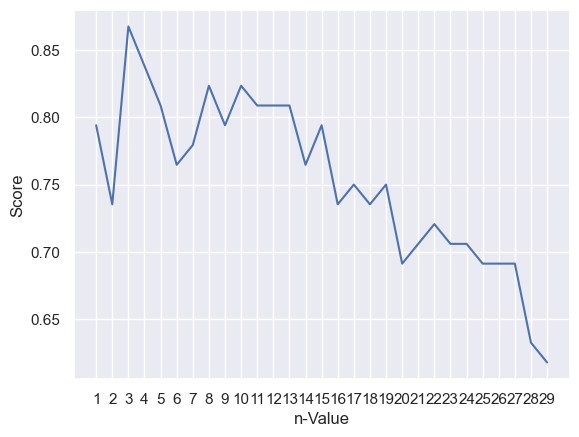

In [95]:
knnScore = []
for i in range(1, 30):
  knnClassifier = KNeighborsClassifier(n_neighbors=i)
  knnClassifier.fit(X_train,y_train)
  knnScore.append(knnClassifier.score(X_test, y_test))

plt.plot(range(1,30), knnScore)
plt.xticks(np.arange(1,30,1))
plt.xlabel("n-Value")
plt.ylabel("Score")
plt.show()

In [96]:
knnAcc = max(knnScore)

print("KNN Accuracy : {:.2f}%".format(knnAcc*100))

KNN Accuracy : 86.76%


## SVM

In [97]:
from sklearn.svm import SVC

In [98]:
sv = SVC(kernel='rbf', max_iter = 600)
sv.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [99]:
y_pred = sv.predict(X_test)

print("Classificiation Report: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

svAcc = accuracy_score(y_pred, y_test)
print("SVC Accuracy: {:.2f}%".format(svAcc*100))


Classificiation Report:                precision    recall  f1-score   support

           0       0.72      0.93      0.81        30
           1       0.93      0.71      0.81        38

    accuracy                           0.81        68
   macro avg       0.82      0.82      0.81        68
weighted avg       0.84      0.81      0.81        68

Confusion Matrix:  [[28  2]
 [11 27]]
SVC Accuracy: 80.88%


## Decision Trees

In [100]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier().fit(X_train,y_train)


accuracy_score(y_test,dtree.predict(X_test))

0.8088235294117647

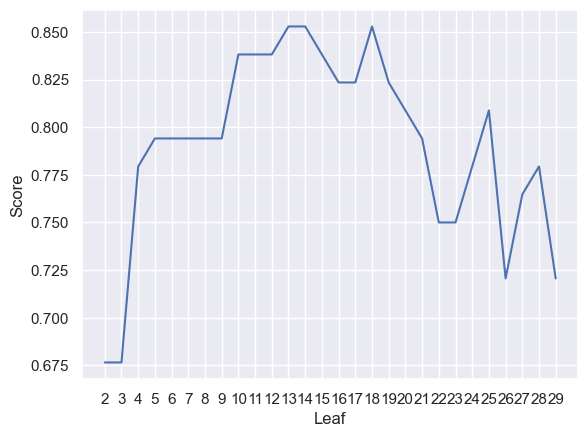

In [101]:
scoreDTree = []
for i in range(2, 30):
  dtree = DecisionTreeClassifier(max_leaf_nodes = i).fit(X_train,y_train)
  scoreDTree.append(dtree.score(X_test, y_test))


plt.plot(range(2,30), scoreDTree)
plt.xticks(np.arange(2,30,1))
plt.xlabel("Leaf")
plt.ylabel("Score")
plt.show()

In [102]:
dtAcc = max(scoreDTree)
print("Decision Tree Accuracy : {:.2f}%".format(dtAcc*100))

Decision Tree Accuracy : 85.29%


## Random Forest

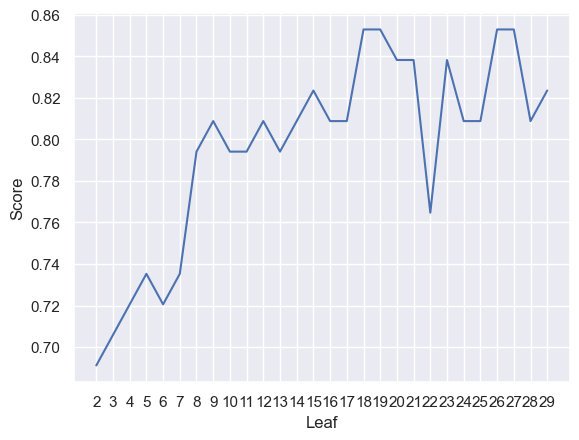

In [103]:
from sklearn.ensemble import RandomForestClassifier

scoreRfTree = []
for i in range(2, 30):
  rf = RandomForestClassifier(n_estimators=100, max_leaf_nodes = i).fit(X_train,y_train)
  scoreRfTree.append(rf.score(X_test, y_test))


plt.plot(range(2,30), scoreRfTree)
plt.xticks(np.arange(2,30,1))
plt.xlabel("Leaf")
plt.ylabel("Score")
plt.show()

In [104]:
rfAcc = max(scoreRfTree)
print("Random Forest Accuracy: {:.2f}%".format(rfAcc*100))

Random Forest Accuracy: 85.29%


## Gradient Boosting

In [105]:
from sklearn.ensemble import GradientBoostingClassifier

In [106]:
gb = GradientBoostingClassifier(subsample = 0.5,
                           n_estimators=500,
                           max_depth=4,
                           max_leaf_nodes = 12)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,500
,subsample,0.5
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [107]:
y_pred = gb.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.77      0.74        30
           1       0.81      0.76      0.78        38

    accuracy                           0.76        68
   macro avg       0.76      0.76      0.76        68
weighted avg       0.77      0.76      0.77        68

[[23  7]
 [ 9 29]]


In [108]:
gbAcc = accuracy_score(y_pred, y_test)
print("Gradient Boosting Accuracy: {:.2f}%".format(gbAcc*100))

Gradient Boosting Accuracy: 76.47%


# model comaprison

In [109]:
lrAcc, knnAcc, svAcc, dtAcc, rfAcc, gbAcc

(0.7941176470588235,
 0.8676470588235294,
 0.8088235294117647,
 0.8529411764705882,
 0.8529411764705882,
 0.7647058823529411)

In [110]:
pd.DataFrame({"Model":['Logisitic regression',
                       'K Neighbors Classifier',
                       'SVM Classifier',
                       'Decision Tree Classifier',
                       'RandomForest  Classifier',
                       'Gradient Boosting Classifier'],
              "Accuracy":[lrAcc*100,
                          knnAcc*100,
                          svAcc*100,
                          dtAcc*100,
                          rfAcc*100,
                          gbAcc*100]}).sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
1,K Neighbors Classifier,86.764706
3,Decision Tree Classifier,85.294118
4,RandomForest Classifier,85.294118
2,SVM Classifier,80.882353
0,Logisitic regression,79.411765
5,Gradient Boosting Classifier,76.470588


In [111]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Self_Employed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,76.478755,0.000000,12.100089,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1,1
4,77.459667,0.000000,11.874342,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1,1
13,43.046487,53.291650,10.677078,360.0,1.0,1,0,1,0,0,0,1,0,1,0,0,0
15,70.356236,0.000000,11.180340,360.0,1.0,1,0,1,0,0,0,1,0,0,0,1,1
19,50.990195,59.160798,10.723805,360.0,1.0,1,1,1,0,0,0,1,0,0,0,1,1


In [112]:
# Create a sample data point (replace with your desired values)
# The order of columns must match the training data after preprocessing
sample_data = [[0, 0, 150, 360, 1.0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0]] # Example: ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Gender_Male, Married, Dependents_0, Dependents_1, Dependents_2, Dependents_3+, Education_Graduate, Self_Employed, Property_Area_Rural, Property_Area_Semiurban, Property_Area_Urban

# Convert to DataFrame for easier preprocessing
sample_df = pd.DataFrame(sample_data, columns=df.drop('Loan_Status', axis=1).columns)

# Apply the same transformations as the training data
# Square root transformation for skewed numerical features
sample_df['ApplicantIncome'] = np.sqrt(sample_df['ApplicantIncome'])
sample_df['LoanAmount'] = np.sqrt(sample_df['LoanAmount'])
sample_df['CoapplicantIncome'] = np.sqrt(sample_df['CoapplicantIncome'])

# MinMax Scaling (using the scaler fitted on the training data)
sample_scaled = MinMaxScaler().fit(X_train).transform(sample_df)


# Predict using the trained KNN model
predicted_status = knn.predict(sample_scaled)

# Map the prediction back to 'Y' or 'N'
loan_status = 'Y' if predicted_status[0] == 1 else 'N'

print(f"Predicted Loan Status: {loan_status}")

Predicted Loan Status: N


In [113]:
import joblib

# Save the trained KNN model
joblib.dump(knn, 'loan_prediction_model.pkl')

# Save the scaler for preprocessing
scaler = MinMaxScaler().fit(X_train)
joblib.dump(scaler, 'scaler.pkl')

# Save feature column names for the Streamlit app
joblib.dump(df.drop('Loan_Status', axis=1).columns.tolist(), 'feature_columns.pkl')

print("Model saved successfully!")
print("Files created: loan_prediction_model.pkl, scaler.pkl, feature_columns.pkl")

Model saved successfully!
Files created: loan_prediction_model.pkl, scaler.pkl, feature_columns.pkl
